# Trabalho Computacional 01 — Atividade 01: Sintonizando o PID

Este notebook é autocontido e implementa **somente a Atividade 01**. O arquivo `Aula04-OLevitador_Magnetico_ODE.ipynb` foi usado como referência e permanece inalterado.

## 1. Objetivo

O objetivo é encontrar um controlador PID capaz de estabilizar o levitador magnético quando sua posição inicial é perturbada segundo

$$x(0)=x_0+\epsilon.$$

Primeiro será demonstrada a estabilidade para $|\epsilon|<0{,}03x_0$. Depois, mantendo os ganhos fixos, será estimada numericamente a faixa de perturbações iniciais aceita pelo modelo e pelo limite de corrente de 2 A.

## 2. Parâmetros do sistema

São utilizados os parâmetros específicos do Trabalho Computacional 01:

| Símbolo | Valor | Unidade | Descrição |
|---:|---:|:---:|:---|
| $m$ | 0,073 | kg | massa da esfera |
| $g$ | 9,81 | m/s² | aceleração da gravidade |
| $k$ | $6{,}51\times10^{-5}$ | N·m²/A² | constante magnética |
| $R$ | 11,0 | Ω | resistência da bobina |
| $x_0$ | $8{,}5\times10^{-3}$ | m | posição nominal |
| $v_0$ | 0 | m/s | velocidade nominal |

O limite admissível da fonte é $|i(t)|\leq2$ A.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy.integrate import solve_ivp
from IPython.display import display, Markdown

# Parâmetros do Trabalho Computacional 01
m = 0.073       # kg
g = 9.81        # m/s²
k = 6.51e-5     # N.m²/A²
R = 11.0        # ohm
x0 = 8.5e-3     # m
v0 = 0.0        # m/s
I_MAX = 2.0     # A

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True})

## 3. Modelo matemático

Para manter compatibilidade com o modelo didático da disciplina, são adotadas sem alteração as relações

$$L(x)=\frac{k}{x},\qquad
f_m(i,x)=\frac{k i^2}{2x^2},\qquad
Bl(i,x)=\frac{k i}{2x^2}.$$

As equações do modelo são

$$\dot i=-\frac{R}{L(x)}i-\frac{Bl(i,x)}{L(x)}v+\frac{u}{L(x)},$$

$$\dot x=v,$$

$$\dot v=g-\frac{f_m(i,x)}{m}.$$

**Observação:** outras formulações eletromecânicas podem derivar o termo de movimento diretamente de $d[L(x)i]/dt$. Nesta atividade, porém, conserva-se deliberadamente a formulação usada pelo professor; nenhuma correção física silenciosa é introduzida.

In [2]:
def L(x):
    """Indutância do modelo didático (H)."""
    return k / x

def fm(i, x):
    """Módulo da força magnética (N)."""
    return k * i**2 / (2.0 * x**2)

def Bl(i, x):
    """Fator de força adotado no notebook da disciplina (N/A)."""
    return k * i / (2.0 * x**2)

## 4. Ponto de equilíbrio

No equilíbrio, $v_0=0$ e $\dot v=0$. Logo,

$$mg=f_m(i_0,x_0)=\frac{k i_0^2}{2x_0^2},$$

de onde, escolhendo a corrente nominal positiva,

$$\boxed{i_0=x_0\sqrt{\frac{2mg}{k}}}.$$

Como $v_0=0$ e $\dot i=0$, a equação elétrica fornece

$$0=-\frac{R}{L(x_0)}i_0+\frac{u_0}{L(x_0)},$$

portanto

$$\boxed{u_0=Ri_0}.$$

In [3]:
i0 = x0 * np.sqrt(2.0 * m * g / k)
u0 = R * i0

di0 = (-R * i0 - Bl(i0, x0) * v0 + u0) / L(x0)
dx0 = v0
dv0 = g - fm(i0, x0) / m

print(f'i0 = {i0:.9f} A')
print(f'u0 = {u0:.9f} V')
print('Verificação numérica do equilíbrio:')
print(f'  di/dt = {di0:.3e} A/s')
print(f'  dx/dt = {dx0:.3e} m/s')
print(f'  dv/dt = {dv0:.3e} m/s²')

i0 = 1.260780151 A
u0 = 13.868581664 V
Verificação numérica do equilíbrio:
  di/dt = 0.000e+00 A/s
  dx/dt = 0.000e+00 m/s
  dv/dt = 0.000e+00 m/s²


## 5. Representação em espaço de estados

Com o integrador do PID, o vetor de estados é

$$
y=\begin{bmatrix}i\\x\\v\\E\end{bmatrix},
\qquad E(t)=\int_0^t e(\tau)\,d\tau.
$$

As quatro derivadas são

$$
\begin{aligned}
\dot i &= -\frac{R}{L(x)}i-\frac{Bl(i,x)}{L(x)}v+\frac{u}{L(x)},\\
\dot x &= v,\\
\dot v &= g-\frac{f_m(i,x)}{m},\\
\dot E &= x-x_0.
\end{aligned}
$$

## 6. Controlador PID

A convenção de erro determinada no enunciado é

$$e=x-x_0,$$

de modo que $\dot e=v$. A tensão aplicada é

$$\boxed{u=u_0+K_pe+K_iE+K_dv}.$$

Com essa convenção, um afastamento positivo pede aumento da tensão e da atração magnética. Portanto, ganhos positivos são compatíveis com o sentido de $x$ adotado no modelo.

In [4]:
def control_voltage(x, v, E, Kp, Ki, Kd):
    error = x - x0
    return u0 + Kp * error + Ki * E + Kd * v

def state_derivative(t, y, Kp, Ki, Kd):
    i, x, v, E = y
    u = control_voltage(x, v, E, Kp, Ki, Kd)
    di = (-R * i - Bl(i, x) * v + u) / L(x)
    dx = v
    dv = g - fm(i, x) / m
    dE = x - x0
    return np.array([di, dx, dv, dE])

## 7. Função de simulação

`simulate_pid` recebe os três ganhos, a perturbação e o tempo final. A integração usa uma malha regular, tolerâncias explícitas e um evento terminal antes da singularidade $x=0$. A tensão **não** é recortada e a corrente **não** é saturada: violações permanecem visíveis para o critério de estabilidade.

In [5]:
def simulate_pid(Kp, Ki, Kd, epsilon, t_final=5.0, n_points=1201):
    if x0 + epsilon <= 0:
        raise ValueError('A condição inicial exige x0 + epsilon > 0.')

    y_initial = [i0, x0 + epsilon, v0, 0.0]
    t_eval = np.linspace(0.0, t_final, n_points)

    def rhs(t, y):
        return state_derivative(t, y, Kp, Ki, Kd)

    def minimum_gap_event(t, y):
        return y[1] - 1.0e-6

    minimum_gap_event.terminal = True
    minimum_gap_event.direction = -1

    sol = solve_ivp(
        rhs, (0.0, t_final), y_initial,
        t_eval=t_eval, events=minimum_gap_event,
        rtol=1e-7, atol=1e-9, max_step=0.01,
    )

    i, x, v, E = sol.y
    error = x - x0
    voltage = control_voltage(x, v, E, Kp, Ki, Kd)
    completed = sol.success and sol.t.size == t_eval.size

    return {
        'solution': sol, 't': sol.t, 'i': i, 'x': x, 'v': v, 'E': E,
        'error': error, 'u': voltage, 'epsilon': epsilon,
        'completed': completed, 'message': sol.message,
        'gains': (Kp, Ki, Kd), 't_final': t_final,
    }

## 8. Sintonia do PID

A busca parte de uma aproximação linear no equilíbrio. Foram escolhidos polos lentos de referência em $-10$, $-15$ e $-20$ rad/s; o quarto polo é determinado pela dinâmica elétrica. A correspondência dos coeficientes do polinômio característico fornece ganhos-base.

Para que a escolha não dependa de uma única aproximação, realiza-se uma busca finita e reproduzível: cada ganho-base é multiplicado por 0,8, 1,0 ou 1,2. Os 27 candidatos são simulados para perturbações de $\pm1\%$ e $\pm3\%$ de $x_0$. A função objetivo penaliza erro, velocidade, esforço incremental de corrente, resíduos finais, falha de integração e corrente acima de 2 A. O menor custo define os ganhos usados nas demais seções.

In [6]:
def linearized_matrix(Kp, Ki, Kd):
    a = -R / L(x0)
    b = -Bl(i0, x0) / L(x0)
    c = -2.0 * g / i0
    d = 2.0 * g / x0
    q = 1.0 / L(x0)
    return np.array([
        [a, q*Kp, b + q*Kd, q*Ki],
        [0.0, 0.0, 1.0, 0.0],
        [c, d, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
    ])

# A soma dos polos deve reproduzir o traço fixo da matriz.
slow_poles = np.array([-10.0, -15.0, -20.0])
electrical_rate = R / L(x0)
target_poles = np.r_[slow_poles, -(electrical_rate + slow_poles.sum())]
target_coefficients = np.poly(target_poles)

zero_gains = np.zeros(3)
base_coefficients = np.poly(linearized_matrix(*zero_gains))
coefficient_sensitivity = np.column_stack([
    np.poly(linearized_matrix(*np.eye(3)[j])) - base_coefficients
    for j in range(3)
])
base_gains = np.linalg.lstsq(
    coefficient_sensitivity[1:],
    target_coefficients[1:] - base_coefficients[1:],
    rcond=None,
)[0]

print('Polos lineares desejados:', np.sort(target_poles))
print('Ganhos-base [Kp, Ki, Kd]:', base_gains)
print('Polos obtidos:', np.sort(np.linalg.eigvals(linearized_matrix(*base_gains))))

Polos lineares desejados: [-1391.25192   -20.        -15.        -10.     ]
Ganhos-base [Kp, Ki, Kd]: [2078.137376 2054.137231   32.835976]
Polos obtidos: [-1391.25192+0.j   -20.     +0.j   -15.     +0.j   -10.     +0.j]


In [7]:
def tuning_cost(gains):
    total = 0.0
    for percent in (-3.0, -1.0, 1.0, 3.0):
        result = simulate_pid(*gains, percent/100.0*x0, t_final=3.0, n_points=601)
        if not result['completed'] or not np.all(np.isfinite(result['solution'].y)):
            return np.inf
        t, error, v, i = result['t'], result['error'], result['v'], result['i']
        max_current = np.max(np.abs(i))
        total += (
            5e5 * np.trapezoid(error**2, t)
            + 100.0 * np.trapezoid(v**2, t)
            + 2.0 * np.trapezoid((i-i0)**2, t)
            + 2e6 * error[-1]**2
            + 1e4 * v[-1]**2
            + 1e6 * max(0.0, max_current-I_MAX)**2
        )
    return total

scale_values = (0.8, 1.0, 1.2)
tuning_rows = []
for scales in product(scale_values, repeat=3):
    gains = base_gains * np.array(scales)
    tuning_rows.append({
        'Kp': gains[0], 'Ki': gains[1], 'Kd': gains[2],
        'scale_Kp': scales[0], 'scale_Ki': scales[1], 'scale_Kd': scales[2],
        'cost': tuning_cost(gains),
    })

tuning_table = pd.DataFrame(tuning_rows).sort_values('cost').reset_index(drop=True)
Kp, Ki, Kd = tuning_table.loc[0, ['Kp', 'Ki', 'Kd']].to_numpy(dtype=float)

display(tuning_table.head(10).style.format({'Kp':'{:.3f}', 'Ki':'{:.3f}', 'Kd':'{:.3f}', 'cost':'{:.6g}'}))
print(f'Ganhos selecionados: Kp={Kp:.6f}, Ki={Ki:.6f}, Kd={Kd:.6f}')
print('Motivo: menor custo entre os candidatos, incluindo as quatro perturbações e o limite de corrente.')

,Kp,Ki,Kd,scale_Kp,scale_Ki,scale_Kd,cost
0,2493.765,1643.310,32.836,1.200000,0.800000,1.000000,0.00286399
1,2493.765,2054.137,32.836,1.200000,1.000000,1.000000,0.00290281
2,2493.765,1643.310,39.403,1.200000,0.800000,1.200000,0.00292791
3,2493.765,1643.310,26.269,1.200000,0.800000,0.800000,0.00293677
4,2493.765,2464.965,32.836,1.200000,1.200000,1.000000,0.00294256
5,2493.765,2054.137,39.403,1.200000,1.000000,1.200000,0.00296102
6,2493.765,2054.137,26.269,1.200000,1.000000,0.800000,0.00298673
7,2493.765,2464.965,39.403,1.200000,1.200000,1.200000,0.00299478
8,2493.765,2464.965,26.269,1.200000,1.200000,0.800000,0.00303825
9,2078.137,1643.310,26.269,1.000000,0.800000,0.800000,0.0041773


Ganhos selecionados: Kp=2493.764852, Ki=1643.309785, Kd=32.835976
Motivo: menor custo entre os candidatos, incluindo as quatro perturbações e o limite de corrente.


## 9. Demonstração de estabilidade

Adota-se $\epsilon=0{,}01x_0$, isto é, uma perturbação positiva de 1%, que satisfaz estritamente $|\epsilon|<0{,}03x_0$.

epsilon = 8.500000000e-05 m (1.00% de x0)
Integração concluída: True — The solver successfully reached the end of the integration interval.
Corrente máxima: 1.279570 A
Erro final: -2.550e-10 m
Velocidade final: 3.842e-10 m/s


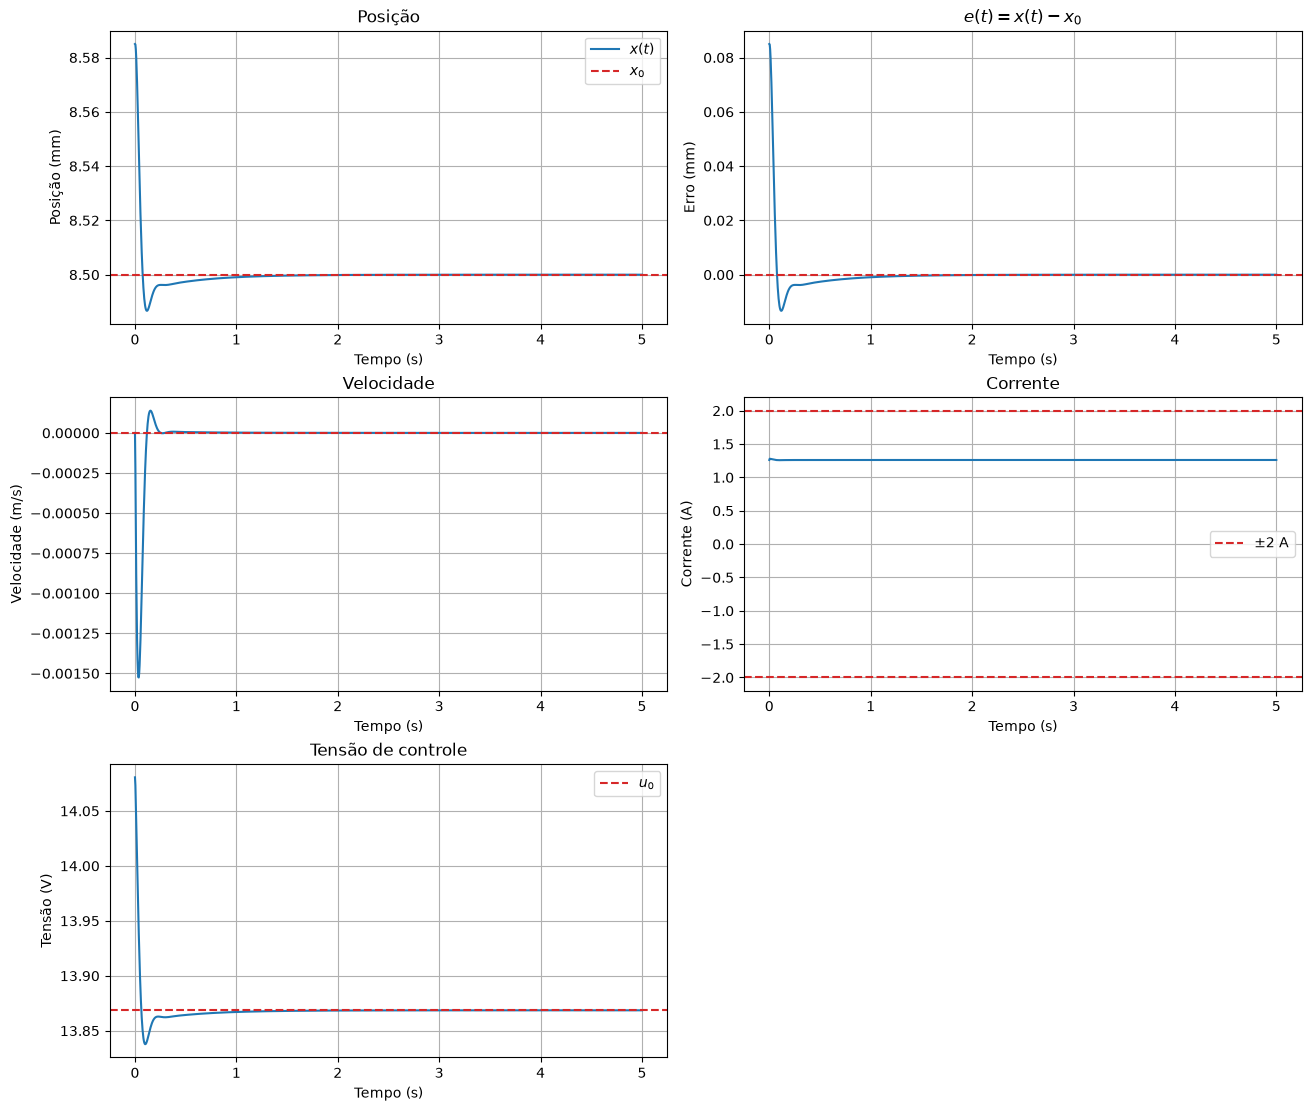

In [8]:
epsilon_demo = 0.01 * x0
demo = simulate_pid(Kp, Ki, Kd, epsilon_demo, t_final=5.0)

print(f'epsilon = {epsilon_demo:.9e} m ({100*epsilon_demo/x0:.2f}% de x0)')
print(f'Integração concluída: {demo["completed"]} — {demo["message"]}')
print(f'Corrente máxima: {np.max(np.abs(demo["i"])):.6f} A')
print(f'Erro final: {demo["error"][-1]:.3e} m')
print(f'Velocidade final: {demo["v"][-1]:.3e} m/s')

fig, axes = plt.subplots(3, 2, figsize=(13, 11), constrained_layout=True)
t = demo['t']

axes[0,0].plot(t, 1e3*demo['x'], label='$x(t)$')
axes[0,0].axhline(1e3*x0, color='tab:red', ls='--', label='$x_0$')
axes[0,0].set(xlabel='Tempo (s)', ylabel='Posição (mm)', title='Posição')
axes[0,0].legend()

axes[0,1].plot(t, 1e3*demo['error'])
axes[0,1].axhline(0, color='tab:red', ls='--')
axes[0,1].set(xlabel='Tempo (s)', ylabel='Erro (mm)', title='$e(t)=x(t)-x_0$')

axes[1,0].plot(t, demo['v'])
axes[1,0].axhline(0, color='tab:red', ls='--')
axes[1,0].set(xlabel='Tempo (s)', ylabel='Velocidade (m/s)', title='Velocidade')

axes[1,1].plot(t, demo['i'])
axes[1,1].axhline(I_MAX, color='tab:red', ls='--', label=r'$\pm2$ A')
axes[1,1].axhline(-I_MAX, color='tab:red', ls='--')
axes[1,1].set(xlabel='Tempo (s)', ylabel='Corrente (A)', title='Corrente')
axes[1,1].legend()

axes[2,0].plot(t, demo['u'])
axes[2,0].axhline(u0, color='tab:red', ls='--', label='$u_0$')
axes[2,0].set(xlabel='Tempo (s)', ylabel='Tensão (V)', title='Tensão de controle')
axes[2,0].legend()

axes[2,1].axis('off')
plt.show()

## 10. Critério de estabilidade

Uma simulação é classificada como estável somente quando todos os critérios abaixo são atendidos:

1. integração concluída até `t_final`;
2. todos os resultados são finitos;
3. $x(t)>0$ durante toda a simulação;
4. $\max|i(t)|\leq2$ A;
5. $|x(t_f)-x_0|\leq10^{-5}$ m;
6. $|v(t_f)|\leq10^{-4}$ m/s.

Essas tolerâncias estão declaradas no código. `sol.success` isoladamente não é considerado evidência de estabilidade.

In [9]:
POSITION_TOL = 1e-5   # m
VELOCITY_TOL = 1e-4   # m/s

def stability_metrics(result):
    arrays = (result['i'], result['x'], result['v'], result['E'], result['u'])
    finite = all(np.all(np.isfinite(values)) for values in arrays)
    positive_position = finite and np.min(result['x']) > 0.0
    max_abs_current = np.max(np.abs(result['i'])) if finite else np.inf
    final_position_error = abs(result['error'][-1]) if finite else np.inf
    final_velocity = abs(result['v'][-1]) if finite else np.inf
    stable = bool(
        result['completed'] and finite and positive_position
        and max_abs_current <= I_MAX
        and final_position_error <= POSITION_TOL
        and final_velocity <= VELOCITY_TOL
    )
    return {
        'stable': stable,
        'completed': result['completed'],
        'finite': finite,
        'positive_position': positive_position,
        'max_abs_current': max_abs_current,
        'final_position_error': final_position_error,
        'final_velocity': final_velocity,
    }

def is_stable(result):
    return stability_metrics(result)['stable']

demo_metrics = stability_metrics(demo)
display(pd.Series(demo_metrics, name='Demonstração de 1%').to_frame())

,Demonstração de 1%
stable,True
completed,True
finite,True
positive_position,True
max_abs_current,1.27957
final_position_error,0.0
final_velocity,0.0


## 11. Faixa de estabilidade em $\epsilon$

Os ganhos selecionados permanecem fixos. A busca inicial cobre perturbações negativas e positivas entre −80% e +80%, incluindo os valores solicitados no enunciado. A tabela registra a perturbação, sua porcentagem, a classificação, a corrente máxima, o erro final e a velocidade final.

In [10]:
initial_percentages = np.array([
    -80, -60, -50, -40, -30, -20, -15, -10, -5, -3, -2, -1,
    0, 1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 60, 80,
], dtype=float)

def evaluate_epsilon(epsilon, t_final=5.0):
    if x0 + epsilon <= 0:
        return {
            'epsilon': epsilon, 'epsilon_percent': 100*epsilon/x0,
            'stable': False, 'max_abs_current': np.inf,
            'final_position_error': np.inf, 'final_velocity': np.inf,
        }
    result = simulate_pid(Kp, Ki, Kd, epsilon, t_final=t_final)
    metrics = stability_metrics(result)
    return {
        'epsilon': epsilon,
        'epsilon_percent': 100.0*epsilon/x0,
        'stable': metrics['stable'],
        'max_abs_current': metrics['max_abs_current'],
        'final_position_error': metrics['final_position_error'],
        'final_velocity': metrics['final_velocity'],
    }

stability_table = pd.DataFrame([
    evaluate_epsilon(percent/100.0*x0) for percent in initial_percentages
])

display(stability_table.style.format({
    'epsilon': '{:.8f}', 'epsilon_percent': '{:.2f}',
    'max_abs_current': '{:.6f}', 'final_position_error': '{:.3e}',
    'final_velocity': '{:.3e}',
}))

,epsilon,epsilon_percent,stable,max_abs_current,final_position_error,final_velocity
0,-0.00680000,-80.00,False,1.260780,7.652e-03,2.508e-01
1,-0.00510000,-60.00,True,1.428431,1.389e-08,2.922e-08
2,-0.00425000,-50.00,True,1.397872,1.139e-08,2.365e-08
3,-0.00340000,-40.00,True,1.370236,9.222e-09,1.992e-08
4,-0.00255000,-30.00,True,1.343130,7.066e-09,1.480e-08
5,-0.00170000,-20.00,True,1.315932,4.830e-09,1.108e-08
6,-0.00127500,-15.00,True,1.302241,3.670e-09,7.900e-09
7,-0.00085000,-10.00,True,1.288482,2.479e-09,5.798e-09
8,-0.00042500,-5.00,True,1.274670,1.256e-09,2.438e-09
9,-0.00025500,-3.00,True,1.269126,7.573e-10,1.338e-09


## 12. Visualização da região estável

As fronteiras são refinadas por bisseção entre $epsilon=0$ — que corresponde ao equilíbrio — e limites externos instáveis. A precisão escolhida é $10^{-4}x_0$, ou 0,01% da posição nominal.

Na fronteira negativa, a perda de estabilidade pode ocorrer por aproximação excessiva do núcleo. Na fronteira positiva, o limite de corrente tende a ser determinante. A classificação inclui simultaneamente todos os critérios da seção anterior.

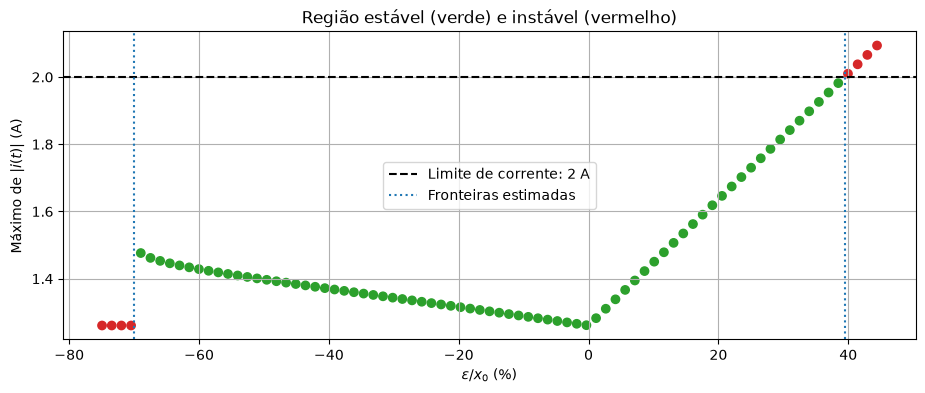

Faixa aproximada de estabilidade:
epsilon_min = -5.944863892e-03 m (-69.940% de x0)
epsilon_max = 3.351855469e-03 m (39.434% de x0)


In [11]:
def refine_boundary(stable_epsilon, unstable_epsilon, tolerance=1e-4*x0):
    """Retorna o último epsilon estável entre um ponto estável e outro instável."""
    stable_point = stable_epsilon
    unstable_point = unstable_epsilon
    assert evaluate_epsilon(stable_point)['stable']
    assert not evaluate_epsilon(unstable_point)['stable']

    while abs(unstable_point - stable_point) > tolerance:
        midpoint = 0.5 * (stable_point + unstable_point)
        if evaluate_epsilon(midpoint)['stable']:
            stable_point = midpoint
        else:
            unstable_point = midpoint
    return stable_point

epsilon_min = refine_boundary(0.0, -0.95*x0)
epsilon_max = refine_boundary(0.0,  0.80*x0)
epsilon_min_percent = 100.0 * epsilon_min/x0
epsilon_max_percent = 100.0 * epsilon_max/x0

refined_percentages = np.linspace(epsilon_min_percent-5, epsilon_max_percent+5, 81)
refined_table = pd.DataFrame([
    evaluate_epsilon(percent/100.0*x0) for percent in refined_percentages
])

colors = refined_table['stable'].map({True: 'tab:green', False: 'tab:red'})
plt.figure(figsize=(11, 4))
plt.scatter(refined_table['epsilon_percent'], refined_table['max_abs_current'], c=colors)
plt.axhline(I_MAX, color='black', ls='--', label='Limite de corrente: 2 A')
plt.axvline(epsilon_min_percent, color='tab:blue', ls=':', label='Fronteiras estimadas')
plt.axvline(epsilon_max_percent, color='tab:blue', ls=':')
plt.xlabel(r'$\epsilon/x_0$ (%)')
plt.ylabel('Máximo de $|i(t)|$ (A)')
plt.title('Região estável (verde) e instável (vermelho)')
plt.legend()
plt.show()

print('Faixa aproximada de estabilidade:')
print(f'epsilon_min = {epsilon_min:.9e} m ({epsilon_min_percent:.3f}% de x0)')
print(f'epsilon_max = {epsilon_max:.9e} m ({epsilon_max_percent:.3f}% de x0)')

## 13. Conclusões

A célula seguinte gera automaticamente o resumo a partir dos resultados calculados nas seções anteriores, evitando divergência entre texto, parâmetros e simulações.

In [12]:
max_current_demo = np.max(np.abs(demo['i']))

summary = fr'''### Resumo automático da Atividade 01

- Corrente de equilíbrio: $i_0={i0:.6f}$ A;
- tensão de equilíbrio: $u_0={u0:.6f}$ V;
- ganhos selecionados: $K_p={Kp:.6f}$, $K_i={Ki:.6f}$ e $K_d={Kd:.6f}$;
- perturbação da demonstração: $\epsilon={epsilon_demo:.9e}$ m ({100*epsilon_demo/x0:.2f}% de $x_0$);
- corrente máxima na demonstração: ${max_current_demo:.6f}$ A;
- classificação da demonstração: **{'estável' if is_stable(demo) else 'instável'}**;
- fronteira inferior: $\epsilon_{{min}}={epsilon_min:.9e}$ m ({epsilon_min_percent:.3f}% de $x_0$);
- fronteira superior: $\epsilon_{{max}}={epsilon_max:.9e}$ m ({epsilon_max_percent:.3f}% de $x_0$).

Os limites são estimativas numéricas dependentes do tempo de simulação e das tolerâncias explícitas adotadas. Dentro dessa definição, o PID retorna ao ponto nominal sem exceder 2 A. A Atividade 02 e a inclusão de ruído não fazem parte deste notebook.
'''
display(Markdown(summary))

### Resumo automático da Atividade 01

- Corrente de equilíbrio: $i_0=1.260780$ A;
- tensão de equilíbrio: $u_0=13.868582$ V;
- ganhos selecionados: $K_p=2493.764852$, $K_i=1643.309785$ e $K_d=32.835976$;
- perturbação da demonstração: $\epsilon=8.500000000e-05$ m (1.00% de $x_0$);
- corrente máxima na demonstração: $1.279570$ A;
- classificação da demonstração: **estável**;
- fronteira inferior: $\epsilon_{min}=-5.944863892e-03$ m (-69.940% de $x_0$);
- fronteira superior: $\epsilon_{max}=3.351855469e-03$ m (39.434% de $x_0$).

Os limites são estimativas numéricas dependentes do tempo de simulação e das tolerâncias explícitas adotadas. Dentro dessa definição, o PID retorna ao ponto nominal sem exceder 2 A. A Atividade 02 e a inclusão de ruído não fazem parte deste notebook.
